# Exploratory Data Analysis (EDA) - Dataset HLS-CMDS

**Tesis:** Clasificación de Sonidos Cardiopulmonares con Machine Learning  
**Autor:** María Constanza Florio  
**Programa:** Maestría en Ciencia de Datos - ITBA  

**Dataset:** HLS-CMDS (Heart and Lung Sounds from Clinical Manikin using Digital Stethoscope)  
**Fuente:** https://data.mendeley.com/datasets/8972jxbpmp/3

---

## Índice
1. Setup y carga de datos
2. Análisis estructural de los datos
3. Análisis de distribuciones
4. Análisis de desbalance de clases
5. Análisis de variables categóricas
6. Análisis de señales de audio
7. Feature Engineering exploratorio
8. Correlación entre features
9. Conclusiones y decisiones para modelado

---
## 1. Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings

import librosa
import librosa.display

from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Ver todas las columnas completas
pd.set_option('display.max_columns', None)

# Ver el contenido completo de cada celda (sin truncar texto)
pd.set_option('display.max_colwidth', None)

# Ver todas las filas
pd.set_option('display.max_rows', None)

# Ancho total del display
pd.set_option('display.width', None)

In [2]:
# Rutas
DATA_DIR = Path("../data")
AUDIO_HS = DATA_DIR / "HS"
AUDIO_LS = DATA_DIR / "LS"
AUDIO_MIX = DATA_DIR / "Mix"

# Cargar metadatos
hs = pd.read_csv(DATA_DIR / "HS.csv")
ls = pd.read_csv(DATA_DIR / "LS.csv")
mix = pd.read_csv(DATA_DIR / "Mix.csv")

---
## 2. Análisis estructural de los datos

### 2.1 Dimensiones y tipos de datos

In [3]:
datasets = {'Heart Sounds': hs, 'Lung Sounds': ls, 'Mixed Sounds': mix}

structure = pd.DataFrame({
    name: {'filas': len(df), 'columnas': len(df.columns), 'columnas_list': df.columns.tolist()}
    for name, df in datasets.items()
}).T
structure

,filas,columnas,columnas_list
Heart Sounds,50,4,"[Gender, Heart Sound Type, Location, Heart Sound ID]"
Lung Sounds,50,4,"[Gender, Lung Sound Type, Location, Lung Sound ID]"
Mixed Sounds,145,7,"[Gender, Heart Sound Type, Lung Sound Type, Location, Heart Sound ID, Lung Sound ID, Mixed Sound ID]"


In [4]:
# Tipos de datos por dataset
for name, df in datasets.items():
    print(f"\n{name}:")
    display(df.dtypes.to_frame('dtype'))


Heart Sounds:


,dtype
Gender,object
Heart Sound Type,object
Location,object
Heart Sound ID,object



Lung Sounds:


,dtype
Gender,object
Lung Sound Type,object
Location,object
Lung Sound ID,object



Mixed Sounds:


,dtype
Gender,object
Heart Sound Type,object
Lung Sound Type,object
Location,object
Heart Sound ID,object
Lung Sound ID,object
Mixed Sound ID,object


### 2.2 Primeras filas de cada dataset

In [5]:
hs.head(10)

,Gender,Heart Sound Type,Location,Heart Sound ID
0,F,Normal,RC,F_N_RC
1,F,Normal,LC,F_N_LC
2,M,Normal,RUSB,M_N_RUSB
3,F,Normal,LUSB,F_N_LUSB
4,F,Normal,LLSB,F_N_LLSB
5,F,Normal,Apex,F_N_A
6,M,Late Diastolic Murmur,LC,M_LDM_LC
7,M,Mid Systolic Murmur,Apex,M_MSM_A
8,F,Normal,RUSB,F_N_RUSB
9,F,Mid Systolic Murmur,Apex,F_MSM_A


In [7]:
hs.tail(10)

,Gender,Heart Sound Type,Location,Heart Sound ID
40,F,Mid Systolic Murmur,LUSB,F_MSM_LUSB
41,F,Mid Systolic Murmur,LLSB,F_MSM_LLSB
42,M,AV Block,RC,M_AVB_RC
43,M,Normal,LLSB,M_N_LLSB
44,M,Mid Systolic Murmur,RUSB,M_MSM_RUSB
45,M,S3,LLSB,M_S3_LLSB
46,F,Early Systolic Murmur,LLSB,F_ESM_LLSB
47,F,Late Systolic Murmur,LLSB,F_LSM_LLSB
48,M,Early Systolic Murmur,Apex,M_ESM_A
49,M,Atrial Fibrillation,RUSB,M_AF_RUSB


In [6]:
ls.head(10)

,Gender,Lung Sound Type,Location,Lung Sound ID
0,M,Normal,RUA,M_N_RUA
1,F,Normal,LUA,F_N_LUA
2,F,Normal,RMA,F_N_RMA
3,F,Normal,LMA,F_N_LMA
4,M,Normal,RLA,M_N_RLA
5,M,Normal,LLA,M_N_LLA
6,M,Pleural Rub,RMA,M_PR_RMA
7,M,Pleural Rub,LUA,M_PR_LUA
8,F,Rhonchi,LUA,F_R_LUA
9,M,Wheezing,LUA,M_W_LUA


In [8]:
mix.head(10)

,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID
0,F,Late Systolic Murmur,Rhonchi,LUSB,H0001,L0001,M0001
1,F,S3,Normal,RLA,H0002,L0002,M0002
2,M,Atrial Fibrillation,Normal,LMA,H0003,L0003,M0003
3,F,S3,Coarse Crackles,Apex,H0004,L0004,M0004
4,M,AV Block,Fine Crackles,RUSB,H0005,L0005,M0005
5,F,S3,Pleural Rub,RC,H0006,L0006,M0006
6,M,Tachycardia,Pleural Rub,Apex,H0007,L0007,M0007
7,F,Early Systolic Murmur,Pleural Rub,LMA,H0008,L0008,M0008
8,M,Mid Systolic Murmur,Wheezing,LUA,H0009,L0009,M0009
9,F,Early Systolic Murmur,Coarse Crackles,LUA,H0010,L0010,M0010


In [9]:
mix.tail(10)

,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID
135,M,Tachycardia,Wheezing,RUSB,H0136,L0136,M0136
136,M,Late Diastolic Murmur,Fine Crackles,Apex,H0137,L0137,M0137
137,M,Tachycardia,Normal,LLA,H0138,L0138,M0138
138,M,S3,Wheezing,LC,H0139,L0139,M0139
139,F,Early Systolic Murmur,Normal,RLA,H0140,L0140,M0140
140,M,S4,Wheezing,Apex,H0141,L0141,M0141
141,F,Mid Systolic Murmur,Normal,RMA,H0142,L0142,M0142
142,F,Early Systolic Murmur,Wheezing,RLA,H0143,L0143,M0143
143,F,AV Block,Normal,LUA,H0144,L0144,M0144
144,M,Late Diastolic Murmur,Normal,RUSB,H0145,L0145,M0145


### 2.3 Valores nulos y duplicados

In [10]:
quality_check = pd.DataFrame({
    'Heart Sounds': {
        'nulos_total': hs.isnull().sum().sum(),
        'duplicados': hs.duplicated().sum(),
        'ids_unicos': hs['Heart Sound ID'].nunique()
    },
    'Lung Sounds': {
        'nulos_total': ls.isnull().sum().sum(),
        'duplicados': ls.duplicated().sum(),
        'ids_unicos': ls['Lung Sound ID'].nunique()
    },
    'Mixed Sounds': {
        'nulos_total': mix.isnull().sum().sum(),
        'duplicados': mix.duplicated().sum(),
        'ids_unicos': mix['Mixed Sound ID'].nunique()
    }
}).T
quality_check

,nulos_total,duplicados,ids_unicos
Heart Sounds,0,0,50
Lung Sounds,0,0,50
Mixed Sounds,0,0,145


---
## 3. Análisis de distribuciones

### 3.1 Distribución de clases - Heart Sounds

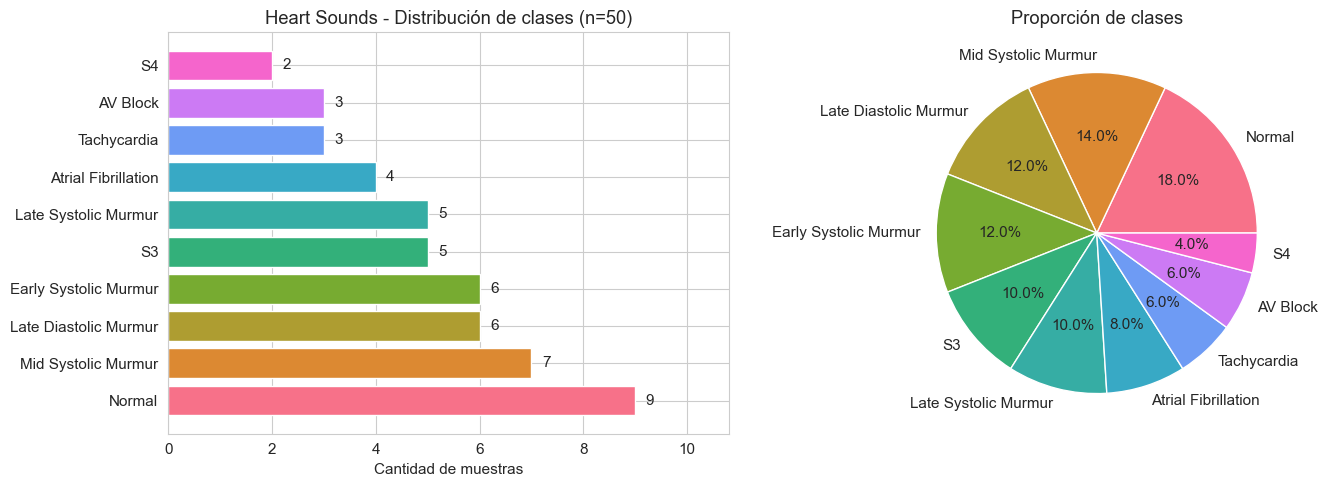

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
hs_counts = hs['Heart Sound Type'].value_counts()
colors = sns.color_palette("husl", len(hs_counts))

# Barplot
ax1 = axes[0]
bars = ax1.barh(hs_counts.index, hs_counts.values, color=colors)
ax1.set_xlabel('Cantidad de muestras')
ax1.set_title(f'Heart Sounds - Distribución de clases (n={len(hs)})')
for bar, val in zip(bars, hs_counts.values):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
ax1.set_xlim(0, max(hs_counts) * 1.2)

# Pie chart
ax2 = axes[1]
ax2.pie(hs_counts.values, labels=hs_counts.index, autopct='%1.1f%%', colors=colors)
ax2.set_title('Proporción de clases')

plt.tight_layout()
plt.savefig('../outputs/01_distribucion_heart_sounds.png', dpi=150, bbox_inches='tight')

### 3.2 Distribución de clases - Lung Sounds

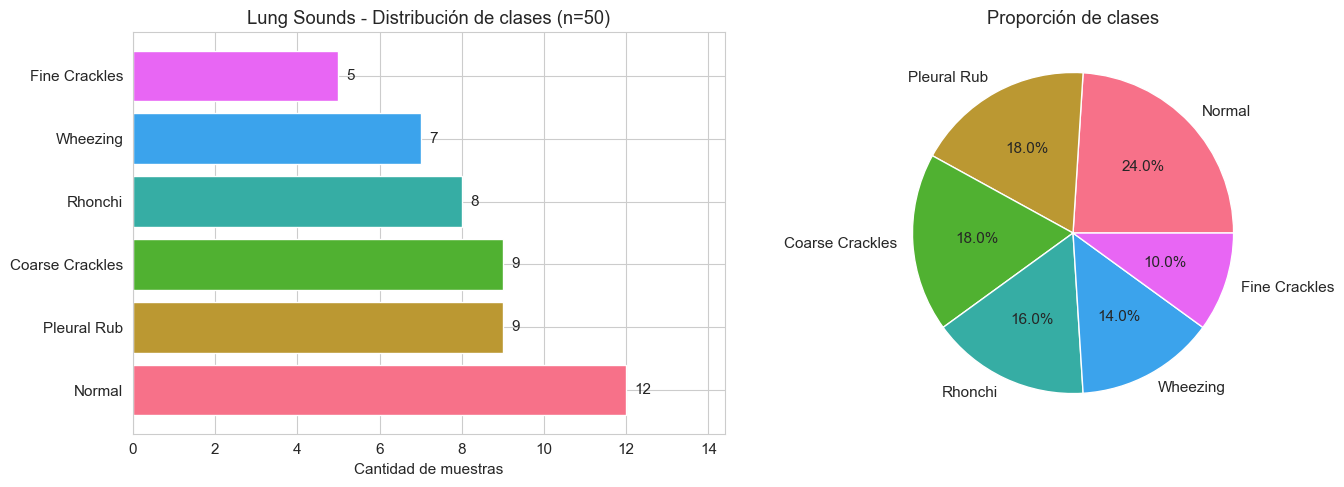

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ls_counts = ls['Lung Sound Type'].value_counts()
colors = sns.color_palette("husl", len(ls_counts))

ax1 = axes[0]
bars = ax1.barh(ls_counts.index, ls_counts.values, color=colors)
ax1.set_xlabel('Cantidad de muestras')
ax1.set_title(f'Lung Sounds - Distribución de clases (n={len(ls)})')
for bar, val in zip(bars, ls_counts.values):
    ax1.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}', va='center')
ax1.set_xlim(0, max(ls_counts) * 1.2)

ax2 = axes[1]
ax2.pie(ls_counts.values, labels=ls_counts.index, autopct='%1.1f%%', colors=colors)
ax2.set_title('Proporción de clases')

plt.tight_layout()
plt.savefig('../outputs/02_distribucion_lung_sounds.png', dpi=150, bbox_inches='tight')

### 3.3 Distribución de clases - Mixed Sounds

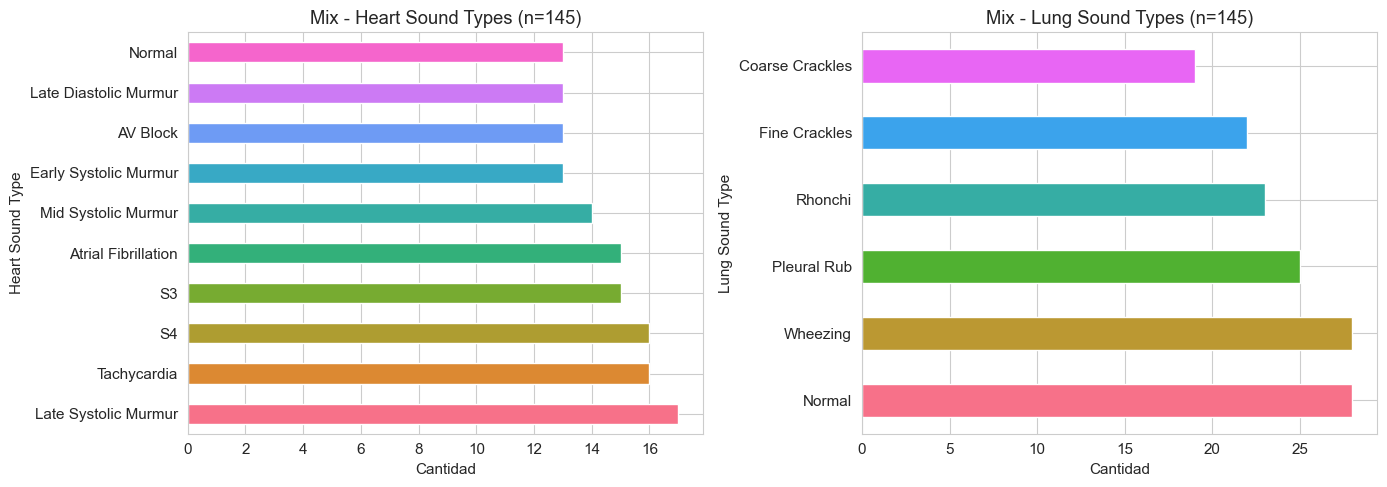

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heart Sound Type en Mix
mix_hs_counts = mix['Heart Sound Type'].value_counts()
ax1 = axes[0]
mix_hs_counts.plot(kind='barh', ax=ax1, color=sns.color_palette("husl", len(mix_hs_counts)))
ax1.set_title(f'Mix - Heart Sound Types (n={len(mix)})')
ax1.set_xlabel('Cantidad')

# Lung Sound Type en Mix
mix_ls_counts = mix['Lung Sound Type'].value_counts()
ax2 = axes[1]
mix_ls_counts.plot(kind='barh', ax=ax2, color=sns.color_palette("husl", len(mix_ls_counts)))
ax2.set_title(f'Mix - Lung Sound Types (n={len(mix)})')
ax2.set_xlabel('Cantidad')

plt.tight_layout()
plt.savefig('../outputs/03_distribucion_mixed_sounds.png', dpi=150, bbox_inches='tight')

### 3.4 Matriz de combinaciones en Mixed Sounds

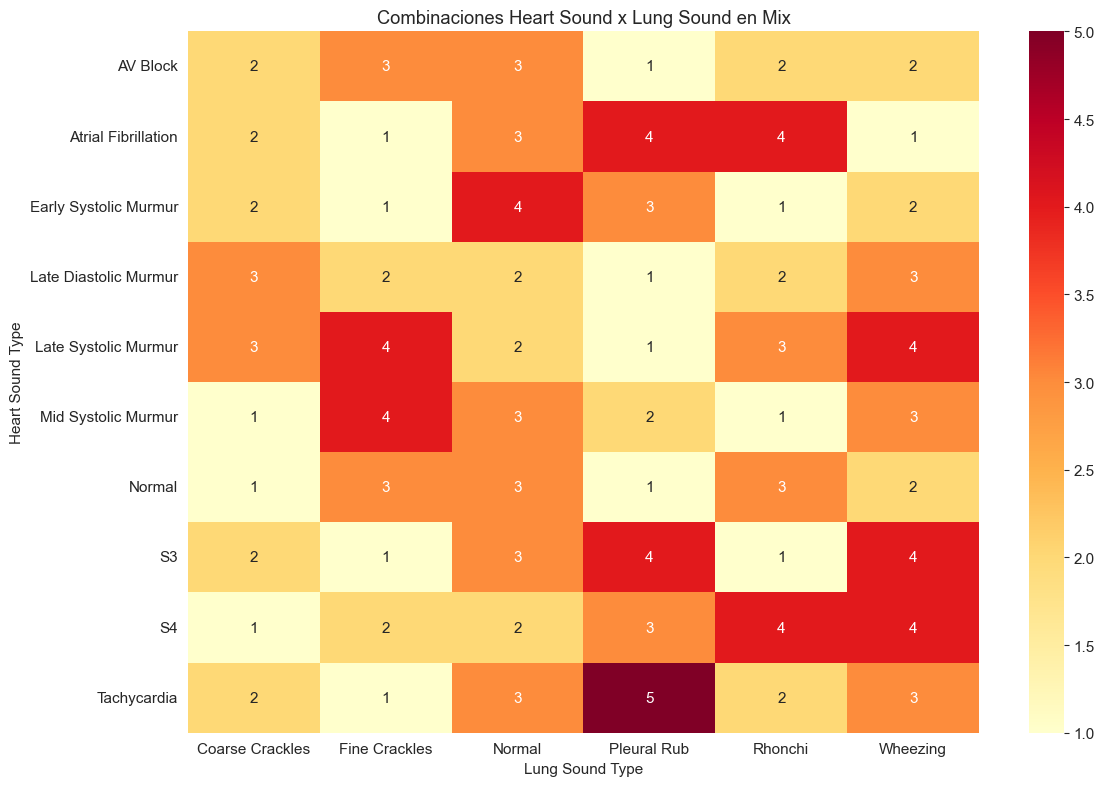

In [17]:
# Crosstab Heart x Lung en Mix
cross = pd.crosstab(mix['Heart Sound Type'], mix['Lung Sound Type'])

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Combinaciones Heart Sound x Lung Sound en Mix')
plt.tight_layout()
plt.savefig('../outputs/04_heatmap_combinaciones_mix.png', dpi=150, bbox_inches='tight')

In [18]:
cross

Lung Sound Type,Coarse Crackles,Fine Crackles,Normal,Pleural Rub,Rhonchi,Wheezing
Heart Sound Type,,,,,,
AV Block,2,3,3,1,2,2
Atrial Fibrillation,2,1,3,4,4,1
Early Systolic Murmur,2,1,4,3,1,2
Late Diastolic Murmur,3,2,2,1,2,3
Late Systolic Murmur,3,4,2,1,3,4
Mid Systolic Murmur,1,4,3,2,1,3
Normal,1,3,3,1,3,2
S3,2,1,3,4,1,4
S4,1,2,2,3,4,4


---
## 4. Análisis de desbalance de clases

### 4.1 Métricas de desbalance

In [19]:
def calculate_imbalance_metrics(series, name):
    """Calcula métricas de desbalance para una serie categórica."""
    counts = series.value_counts()
    total = len(series)
    
    # Entropía normalizada (1 = perfectamente balanceado)
    probs = counts / total
    entropy = -np.sum(probs * np.log2(probs))
    max_entropy = np.log2(len(counts))
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0
    
    return {
        'dataset': name,
        'n_samples': total,
        'n_classes': len(counts),
        'clase_mayoritaria': counts.idxmax(),
        'n_mayoritaria': counts.max(),
        'clase_minoritaria': counts.idxmin(),
        'n_minoritaria': counts.min(),
        'ratio_imbalance': round(counts.max() / counts.min(), 2),
        'balance_score': round(normalized_entropy, 3)
    }

In [20]:
imbalance_report = pd.DataFrame([
    calculate_imbalance_metrics(hs['Heart Sound Type'], 'Heart Sounds'),
    calculate_imbalance_metrics(ls['Lung Sound Type'], 'Lung Sounds'),
    calculate_imbalance_metrics(mix['Heart Sound Type'], 'Mix - Heart'),
    calculate_imbalance_metrics(mix['Lung Sound Type'], 'Mix - Lung')
])
imbalance_report.set_index('dataset')

,n_samples,n_classes,clase_mayoritaria,n_mayoritaria,clase_minoritaria,n_minoritaria,ratio_imbalance,balance_score
dataset,,,,,,,,
Heart Sounds,50,10,Normal,9,S4,2,4.50,0.965
Lung Sounds,50,6,Normal,12,Fine Crackles,5,2.40,0.981
Mix - Heart,145,10,Late Systolic Murmur,17,Early Systolic Murmur,13,1.31,0.998
Mix - Lung,145,6,Normal,28,Coarse Crackles,19,1.47,0.995


### 4.2 Crear etiquetas binarias (Normal vs Patológico)

In [21]:
# Heart Sounds
hs['binary_label'] = (hs['Heart Sound Type'] != 'Normal').astype(int)
hs['binary_class'] = hs['binary_label'].map({0: 'Normal', 1: 'Patológico'})

# Lung Sounds  
ls['binary_label'] = (ls['Lung Sound Type'] != 'Normal').astype(int)
ls['binary_class'] = ls['binary_label'].map({0: 'Normal', 1: 'Patológico'})

# Mixed - dos etiquetas
mix['heart_binary'] = (mix['Heart Sound Type'] != 'Normal').astype(int)
mix['lung_binary'] = (mix['Lung Sound Type'] != 'Normal').astype(int)

In [22]:
# Balance binario
binary_balance = pd.DataFrame({
    'Heart Sounds': hs['binary_class'].value_counts(),
    'Lung Sounds': ls['binary_class'].value_counts()
})
binary_balance

,Heart Sounds,Lung Sounds
binary_class,,
Patológico,41,38
Normal,9,12


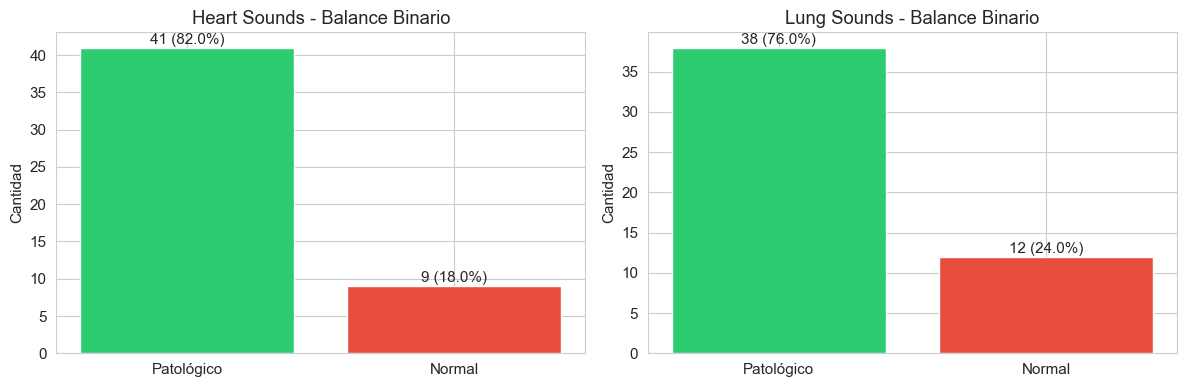

In [24]:
# Visualizar balance binario
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df, col) in zip(axes, [('Heart Sounds', hs, 'binary_class'), 
                                        ('Lung Sounds', ls, 'binary_class')]):
    counts = df[col].value_counts()
    colors = ['#2ecc71', '#e74c3c']  # Verde=Normal, Rojo=Patológico
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f'{name} - Balance Binario')
    ax.set_ylabel('Cantidad')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('../outputs/05_balance_binario.png', dpi=150, bbox_inches='tight')

### 4.3 Resumen de desbalance

In [25]:
imbalance_summary = pd.DataFrame({
    'Clasificación': ['Multiclase HS', 'Multiclase LS', 'Binaria HS', 'Binaria LS'],
    'Clases': [10, 6, 2, 2],
    'Ratio': [4.5, 2.4, 4.56, 3.17],
    'Recomendación': [
        'Agrupar clases o usar SMOTE',
        'Manejable con class_weight',
        'Usar class_weight o SMOTE',
        'Usar class_weight o SMOTE'
    ]
})
imbalance_summary

,Clasificación,Clases,Ratio,Recomendación
0,Multiclase HS,10,4.50,Agrupar clases o usar SMOTE
1,Multiclase LS,6,2.40,Manejable con class_weight
2,Binaria HS,2,4.56,Usar class_weight o SMOTE
3,Binaria LS,2,3.17,Usar class_weight o SMOTE


---
## 5. Análisis de variables categóricas

### 5.1 Distribución por género

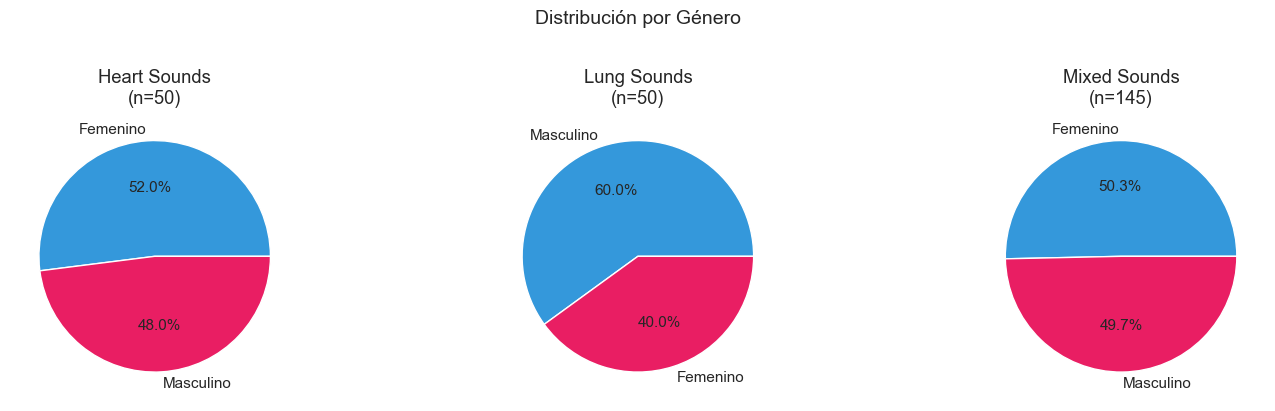

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, datasets.items()):
    counts = df['Gender'].value_counts()
    ax.pie(counts.values, labels=['Masculino' if x=='M' else 'Femenino' for x in counts.index],
           autopct='%1.1f%%', colors=['#3498db', '#e91e63'])
    ax.set_title(f'{name}\n(n={len(df)})')

plt.suptitle('Distribución por Género', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/06_distribucion_genero.png', dpi=150, bbox_inches='tight')

### 5.2 Distribución por localización anatómica

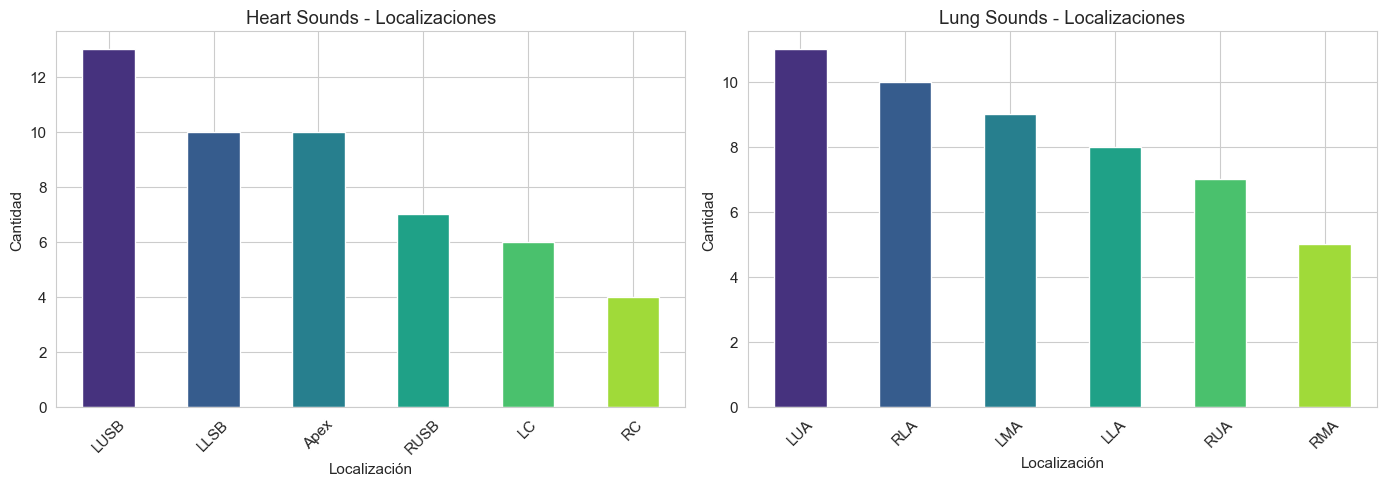

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heart Sounds - Localizaciones
hs_loc = hs['Location'].value_counts()
ax1 = axes[0]
hs_loc.plot(kind='bar', ax=ax1, color=sns.color_palette("viridis", len(hs_loc)))
ax1.set_title('Heart Sounds - Localizaciones')
ax1.set_xlabel('Localización')
ax1.set_ylabel('Cantidad')
ax1.tick_params(axis='x', rotation=45)

# Lung Sounds - Localizaciones
ls_loc = ls['Location'].value_counts()
ax2 = axes[1]
ls_loc.plot(kind='bar', ax=ax2, color=sns.color_palette("viridis", len(ls_loc)))
ax2.set_title('Lung Sounds - Localizaciones')
ax2.set_xlabel('Localización')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/07_distribucion_localizaciones.png', dpi=150, bbox_inches='tight')

### 5.3 Relación entre tipo de sonido y localización

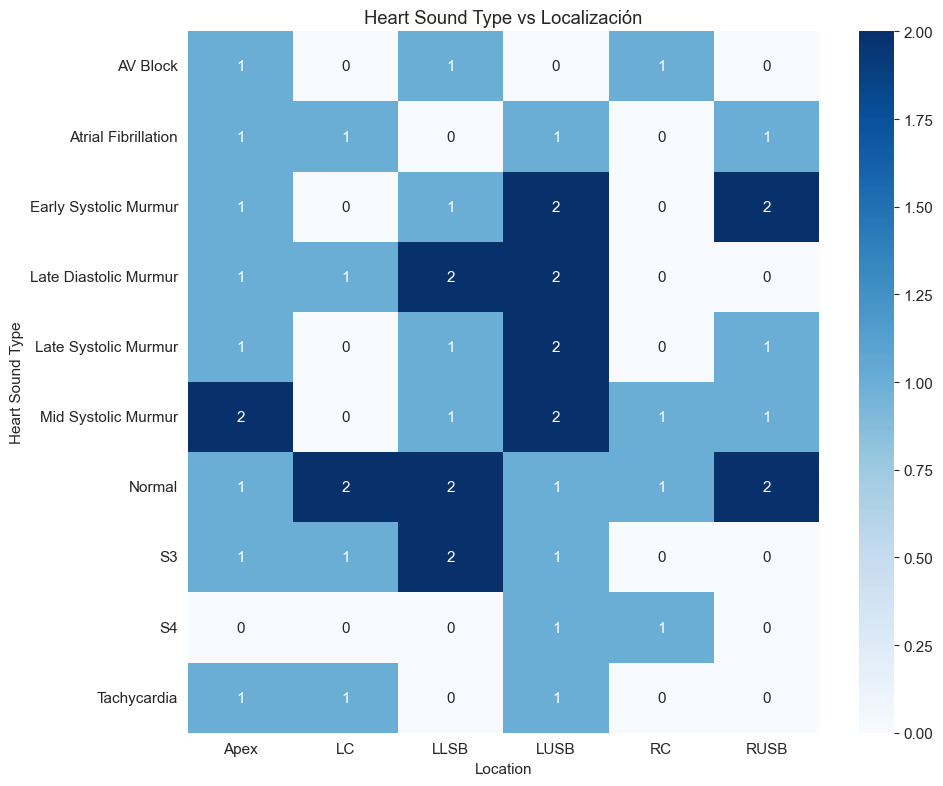

In [29]:
# Heatmap: Tipo de sonido vs Localización para Heart Sounds
cross_hs_loc = pd.crosstab(hs['Heart Sound Type'], hs['Location'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cross_hs_loc, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Heart Sound Type vs Localización')
plt.tight_layout()
plt.savefig('../outputs/08_heatmap_hs_location.png', dpi=150, bbox_inches='tight')

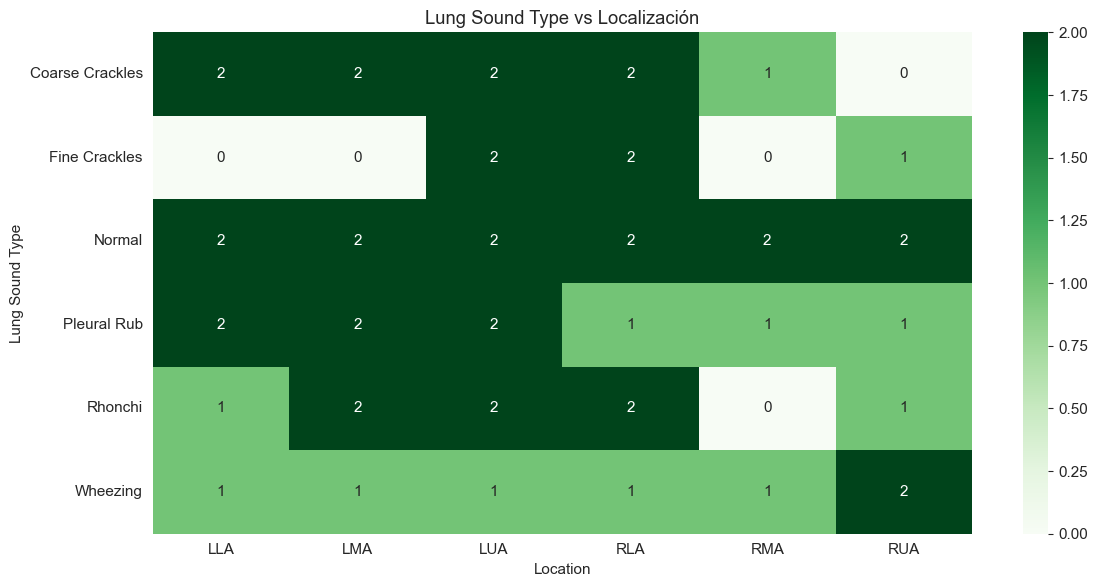

In [31]:
# Heatmap: Tipo de sonido vs Localización para Lung Sounds
cross_ls_loc = pd.crosstab(ls['Lung Sound Type'], ls['Location'])

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(cross_ls_loc, annot=True, fmt='d', cmap='Greens', ax=ax)
ax.set_title('Lung Sound Type vs Localización')
plt.tight_layout()
plt.savefig('../outputs/09_heatmap_ls_location.png', dpi=150, bbox_inches='tight')

---
## 6. Análisis de señales de audio

### 6.1 Cargar y explorar un audio de ejemplo

In [32]:
# Seleccionar un archivo de ejemplo
sample_file = list(AUDIO_HS.glob("*.wav"))[0]
y, sr = librosa.load(sample_file, sr=22050)

audio_info = {
    'archivo': sample_file.name,
    'sample_rate': sr,
    'duracion_segundos': len(y) / sr,
    'n_samples': len(y),
    'amplitud_max': np.max(np.abs(y)),
    'amplitud_media': np.mean(np.abs(y)),
    'rms': np.sqrt(np.mean(y**2))
}
pd.Series(audio_info)

archivo              F_AF_A.wav
sample_rate               22050
duracion_segundos          15.0
n_samples                330750
amplitud_max            0.02498
amplitud_media         0.001243
rms                    0.001815
dtype: object

### 6.2 Visualización completa de un audio

In [33]:
def plot_audio_analysis(filepath, title=None):
    """Genera análisis visual completo de un archivo de audio."""
    y, sr = librosa.load(filepath, sr=22050)
    if title is None:
        title = Path(filepath).stem
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Waveform
    ax1 = axes[0, 0]
    librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title('Forma de Onda')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    
    # Spectrogram
    ax2 = axes[0, 1]
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img2 = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=ax2, cmap='magma')
    ax2.set_title('Espectrograma (STFT)')
    ax2.set_ylim(0, 4000)  # Limitar a frecuencias relevantes
    fig.colorbar(img2, ax=ax2, format='%+2.0f dB')
    
    # Mel Spectrogram
    ax3 = axes[1, 0]
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=2048)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img3 = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax3, cmap='magma', fmax=2048)
    ax3.set_title('Mel Espectrograma')
    fig.colorbar(img3, ax=ax3, format='%+2.0f dB')
    
    # MFCCs
    ax4 = axes[1, 1]
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img4 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=ax4, cmap='coolwarm')
    ax4.set_title('MFCCs (13 coeficientes)')
    ax4.set_ylabel('Coeficiente')
    fig.colorbar(img4, ax=ax4)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

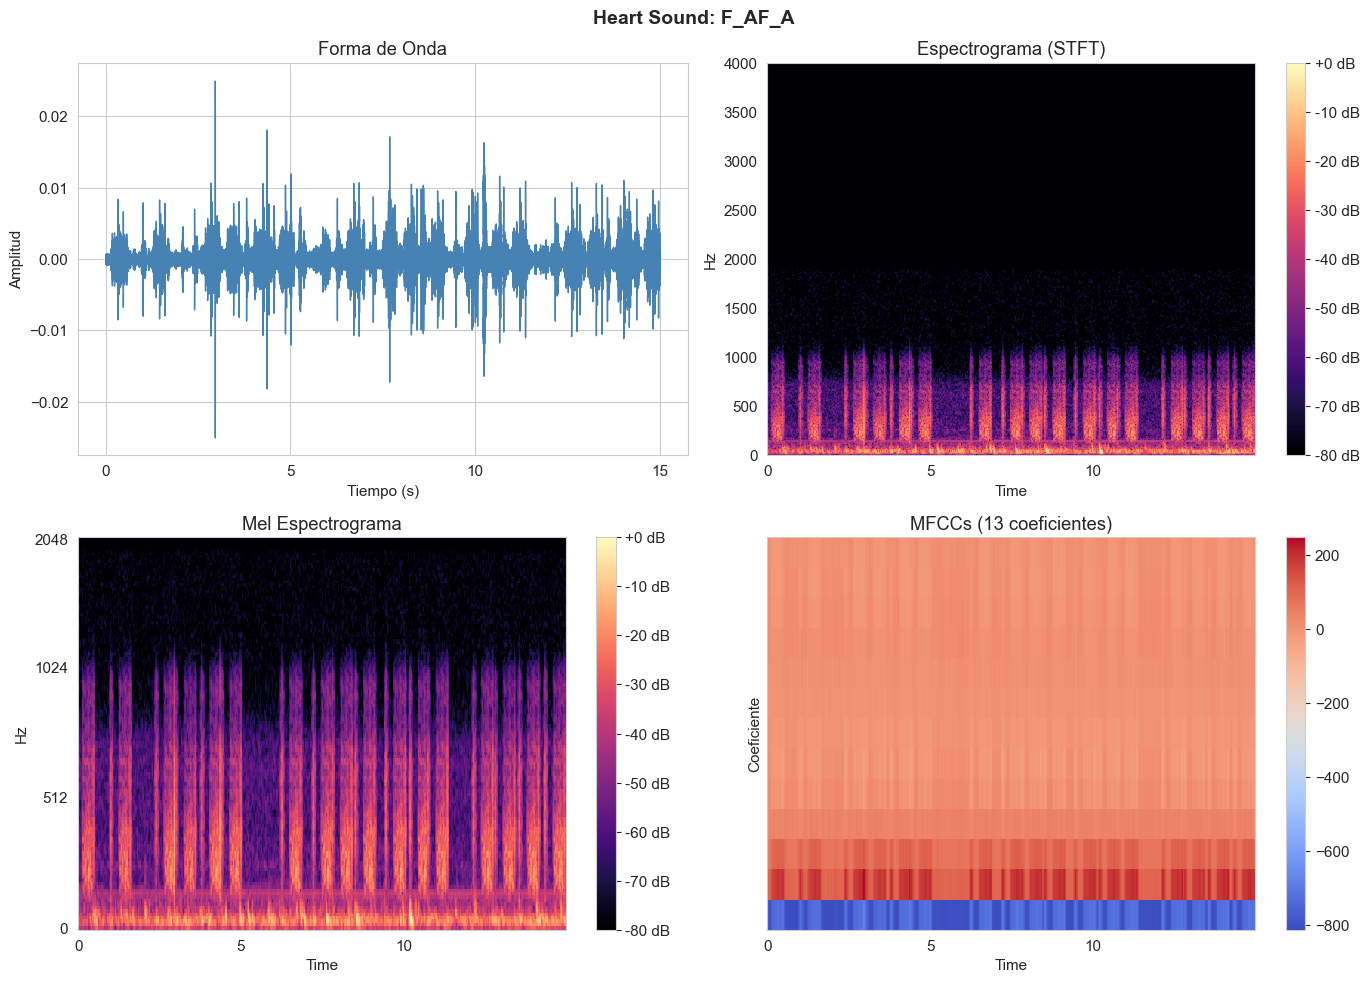

In [34]:
# Analizar ejemplo de Heart Sound
hs_example = list(AUDIO_HS.glob("*.wav"))[0]
fig = plot_audio_analysis(hs_example, f"Heart Sound: {hs_example.stem}")
plt.savefig('../outputs/10_analisis_audio_hs_ejemplo.png', dpi=150, bbox_inches='tight')

### 6.3 Comparación Normal vs Patológico

In [35]:
# Buscar un archivo Normal y uno Patológico
normal_id = hs[hs['Heart Sound Type'] == 'Normal']['Heart Sound ID'].iloc[0]
pathological_id = hs[hs['Heart Sound Type'] != 'Normal']['Heart Sound ID'].iloc[0]
pathological_type = hs[hs['Heart Sound ID'] == pathological_id]['Heart Sound Type'].iloc[0]

normal_file = AUDIO_HS / f"{normal_id}.wav"
pathological_file = AUDIO_HS / f"{pathological_id}.wav"

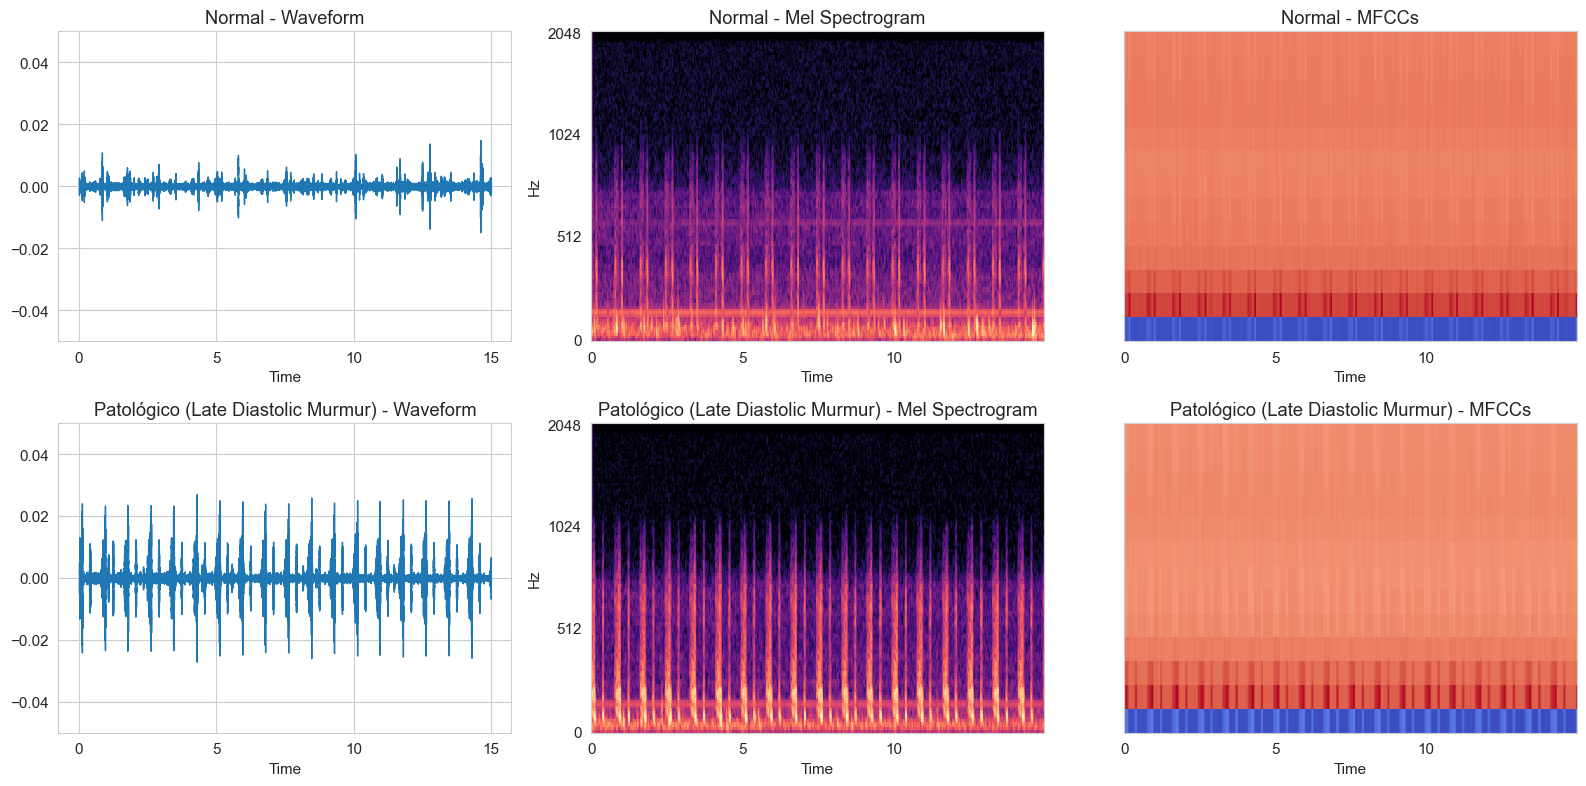

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row, (filepath, label) in enumerate([(normal_file, 'Normal'), 
                                          (pathological_file, f'Patológico ({pathological_type})')]):
    y, sr = librosa.load(filepath, sr=22050)
    
    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[row, 0])
    axes[row, 0].set_title(f'{label} - Waveform')
    axes[row, 0].set_ylim(-0.05, 0.05)
    
    # Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=2048)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=axes[row, 1], cmap='magma', fmax=2048)
    axes[row, 1].set_title(f'{label} - Mel Spectrogram')
    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[row, 2], cmap='coolwarm')
    axes[row, 2].set_title(f'{label} - MFCCs')

plt.tight_layout()
plt.savefig('../outputs/11_comparacion_normal_patologico.png', dpi=150, bbox_inches='tight')

### 6.4 Estadísticas de duración de audios

In [37]:
def get_audio_duration(filepath):
    """Obtiene duración de un archivo de audio."""
    try:
        y, sr = librosa.load(filepath, sr=None)
        return len(y) / sr
    except:
        return None

In [38]:
# Calcular duraciones para cada dataset
hs_durations = [get_audio_duration(AUDIO_HS / f"{id}.wav") for id in hs['Heart Sound ID']]
ls_durations = [get_audio_duration(AUDIO_LS / f"{id}.wav") for id in ls['Lung Sound ID']]

duration_stats = pd.DataFrame({
    'Heart Sounds': pd.Series(hs_durations).describe(),
    'Lung Sounds': pd.Series(ls_durations).describe()
})
duration_stats

,Heart Sounds,Lung Sounds
count,50.0,35.0
mean,15.0,15.0
std,0.0,0.0
min,15.0,15.0
25%,15.0,15.0
50%,15.0,15.0
75%,15.0,15.0
max,15.0,15.0


---
## 7. Feature Engineering exploratorio

### 7.1 Función de extracción de features

In [39]:
def extract_features(y, sr):
    """
    Extrae features de audio para clasificación.
    
    Features extraídas:
    - MFCCs (13) + estadísticas (mean, std, max, min)
    - Delta MFCCs
    - Spectral: centroid, bandwidth, rolloff, contrast, flatness
    - Zero crossing rate
    - RMS energy
    - Tempo
    
    Total: ~100 features
    """
    features = {}
    
    # === MFCCs ===
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f'mfcc_{i+1}_mean'] = np.mean(mfccs[i])
        features[f'mfcc_{i+1}_std'] = np.std(mfccs[i])
        features[f'mfcc_{i+1}_max'] = np.max(mfccs[i])
        features[f'mfcc_{i+1}_min'] = np.min(mfccs[i])
    
    # === Delta MFCCs ===
    mfcc_delta = librosa.feature.delta(mfccs)
    for i in range(13):
        features[f'mfcc_delta_{i+1}_mean'] = np.mean(mfcc_delta[i])
        features[f'mfcc_delta_{i+1}_std'] = np.std(mfcc_delta[i])
    
    # === Spectral Features ===
    # Centroid
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features['spectral_centroid_mean'] = np.mean(spec_cent)
    features['spectral_centroid_std'] = np.std(spec_cent)
    
    # Bandwidth
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features['spectral_bandwidth_mean'] = np.mean(spec_bw)
    features['spectral_bandwidth_std'] = np.std(spec_bw)
    
    # Rolloff
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features['spectral_rolloff_mean'] = np.mean(spec_rolloff)
    features['spectral_rolloff_std'] = np.std(spec_rolloff)
    
    # Contrast
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(spec_contrast.shape[0]):
        features[f'spectral_contrast_{i+1}_mean'] = np.mean(spec_contrast[i])
        features[f'spectral_contrast_{i+1}_std'] = np.std(spec_contrast[i])
    
    # Flatness
    spec_flat = librosa.feature.spectral_flatness(y=y)[0]
    features['spectral_flatness_mean'] = np.mean(spec_flat)
    features['spectral_flatness_std'] = np.std(spec_flat)
    
    # === Zero Crossing Rate ===
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    
    # === RMS Energy ===
    rms = librosa.feature.rms(y=y)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    features['rms_max'] = np.max(rms)
    
    # === Tempo ===
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = float(tempo) if np.isscalar(tempo) else float(tempo[0])
    
    return features

In [40]:
# Test con un archivo
y_test, sr_test = librosa.load(sample_file, sr=22050)
sample_features = extract_features(y_test, sr_test)
f"Features extraídas: {len(sample_features)}"

'Features extraídas: 106'

In [41]:
# Ver algunas features
pd.Series(sample_features).head(20)

mfcc_1_mean   -760.473694
mfcc_1_std      36.328560
mfcc_1_max    -678.274231
mfcc_1_min    -812.170532
mfcc_2_mean    155.824371
mfcc_2_std      42.007370
mfcc_2_max     248.655731
mfcc_2_min      94.891235
mfcc_3_mean     94.748878
mfcc_3_std      20.246008
mfcc_3_max     133.210770
mfcc_3_min      30.380474
mfcc_4_mean     38.346470
mfcc_4_std       5.262313
mfcc_4_max      51.120293
mfcc_4_min      21.507984
mfcc_5_mean      6.976531
mfcc_5_std      14.648028
mfcc_5_max      34.355785
mfcc_5_min     -27.866678
dtype: float64

### 7.2 Extraer features de todo el dataset

In [42]:
from tqdm import tqdm

def process_all_files(metadata_df, audio_dir, id_col, label_col, binary_col=None):
    """Extrae features de todos los archivos de un dataset."""
    records = []
    
    for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
        filepath = audio_dir / f"{row[id_col]}.wav"
        
        if not filepath.exists():
            continue
        
        try:
            y, sr = librosa.load(filepath, sr=22050)
            features = extract_features(y, sr)
            features['file_id'] = row[id_col]
            features['label'] = row[label_col]
            if binary_col:
                features['label_binary'] = row[binary_col]
            records.append(features)
        except Exception as e:
            print(f"Error en {filepath}: {e}")
    
    return pd.DataFrame(records)

In [43]:
# Extraer features - Heart Sounds
hs_features = process_all_files(hs, AUDIO_HS, 'Heart Sound ID', 'Heart Sound Type', 'binary_label')
hs_features.shape

100%|██████████| 50/50 [00:18<00:00,  2.73it/s]


(50, 109)

In [44]:
# Extraer features - Lung Sounds
ls_features = process_all_files(ls, AUDIO_LS, 'Lung Sound ID', 'Lung Sound Type', 'binary_label')
ls_features.shape

100%|██████████| 50/50 [00:13<00:00,  3.78it/s]


(35, 109)

In [46]:
# Guardar features extraídas
hs_features.to_csv('../outputs/hs_features.csv', index=False)
ls_features.to_csv('../outputs/ls_features.csv', index=False)

### 7.3 Estadísticas descriptivas de features

In [47]:
feature_cols = [c for c in hs_features.columns if c not in ['file_id', 'label', 'label_binary']]
hs_features[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mfcc_1_mean,50.0,-736.270752,49.253151,-8.621715e+02,-767.153397,-742.444489,-706.186020,-642.830017
mfcc_1_std,50.0,32.347618,10.287176,1.125952e+01,25.762596,32.556894,38.840914,54.083782
mfcc_1_max,50.0,-619.310303,74.867317,-8.008560e+02,-668.701813,-628.295166,-577.385010,-409.719421
mfcc_1_min,50.0,-779.748413,45.385609,-8.805523e+02,-812.502182,-781.921173,-749.957535,-671.478638
mfcc_2_mean,50.0,137.576126,30.476017,7.170950e+01,116.485058,133.261765,162.434456,217.215744
mfcc_2_std,50.0,37.486073,11.885598,1.344768e+01,30.651406,37.486526,46.073293,63.480629
mfcc_2_max,50.0,220.308014,33.901340,1.567234e+02,203.590572,220.327156,241.113918,288.015778
mfcc_2_min,50.0,85.109711,25.507454,3.585561e+01,66.941376,83.545681,102.947588,135.305054
mfcc_3_mean,50.0,89.168114,10.504411,5.777757e+01,81.490833,88.754501,96.517189,109.588165
mfcc_3_std,50.0,19.848574,5.690465,7.694690e+00,16.348691,19.834265,22.673176,33.437580


---
## 8. Correlación entre features

### 8.1 Matriz de correlación

In [48]:
# Seleccionar subset de features para visualización
mfcc_cols = [c for c in feature_cols if 'mfcc' in c and 'delta' not in c and 'mean' in c]
spectral_cols = [c for c in feature_cols if 'spectral' in c and 'mean' in c]
other_cols = ['zcr_mean', 'rms_mean', 'tempo']

selected_features = mfcc_cols + spectral_cols + other_cols

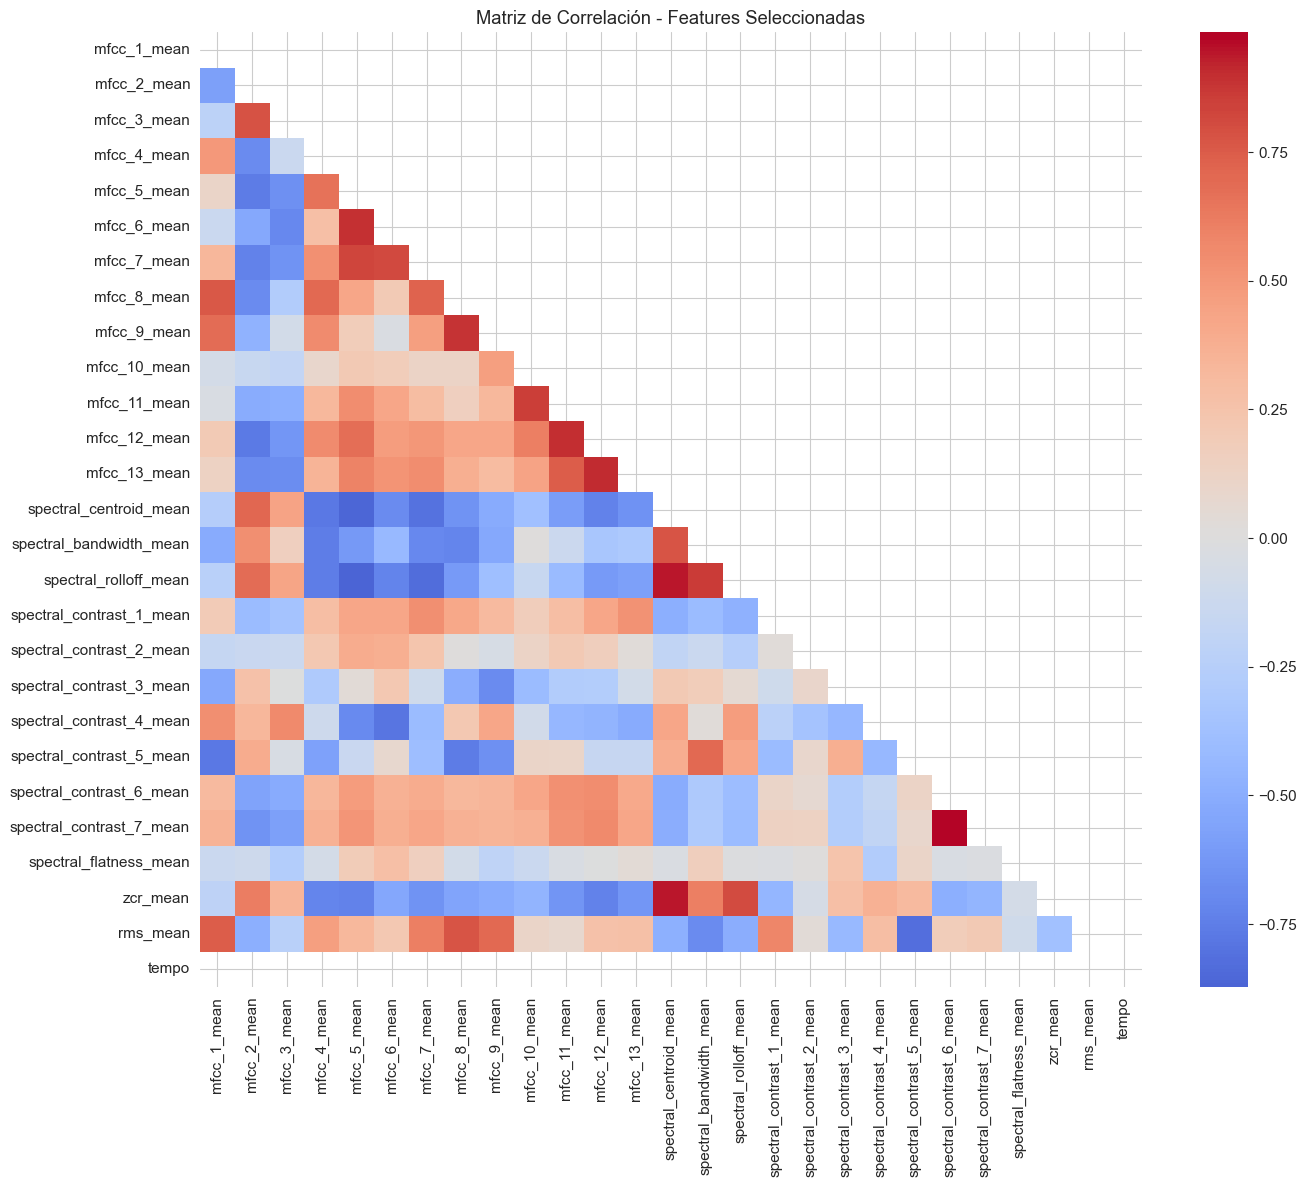

In [49]:
fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = hs_features[selected_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de Correlación - Features Seleccionadas')
plt.tight_layout()
plt.savefig('../outputs/12_correlacion_features.png', dpi=150, bbox_inches='tight')

### 8.2 Features más correlacionadas con la etiqueta binaria

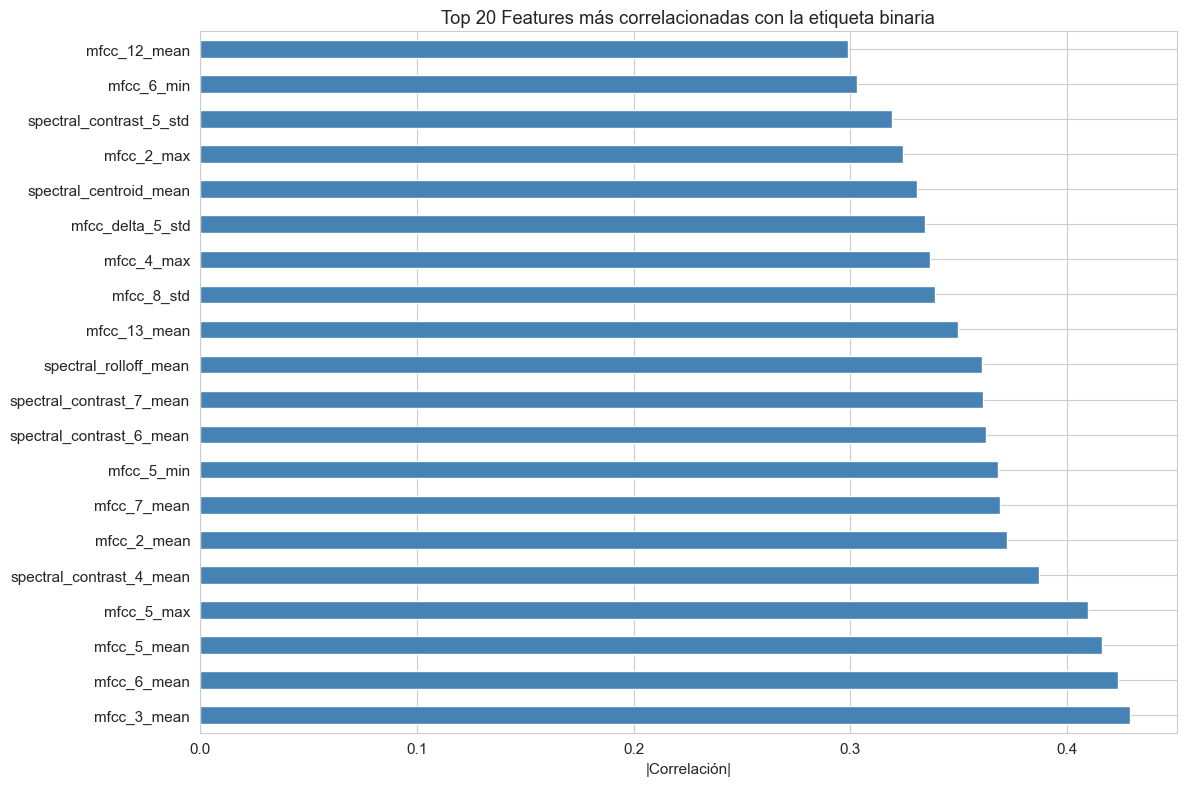

In [51]:
# Correlación con label binario
correlations = hs_features[feature_cols + ['label_binary']].corr()['label_binary'].drop('label_binary')
correlations_sorted = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
correlations_sorted.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features más correlacionadas con la etiqueta binaria')
ax.set_xlabel('|Correlación|')
plt.tight_layout()
plt.savefig('../outputs/13_top_features_correlacion.png', dpi=150, bbox_inches='tight')

In [52]:
# Ver correlaciones
correlations_sorted.head(20)

mfcc_3_mean                 0.429104
mfcc_6_mean                 0.423382
mfcc_5_mean                 0.415981
mfcc_5_max                  0.409489
spectral_contrast_4_mean    0.386770
mfcc_2_mean                 0.372137
mfcc_7_mean                 0.368933
mfcc_5_min                  0.368121
spectral_contrast_6_mean    0.362584
spectral_contrast_7_mean    0.361161
spectral_rolloff_mean       0.360542
mfcc_13_mean                0.349605
mfcc_8_std                  0.338844
mfcc_4_max                  0.336896
mfcc_delta_5_std            0.334317
spectral_centroid_mean      0.330469
mfcc_2_max                  0.324260
spectral_contrast_5_std     0.318985
mfcc_6_min                  0.303154
mfcc_12_mean                0.298807
Name: label_binary, dtype: float64

### 8.3 Distribución de features por clase

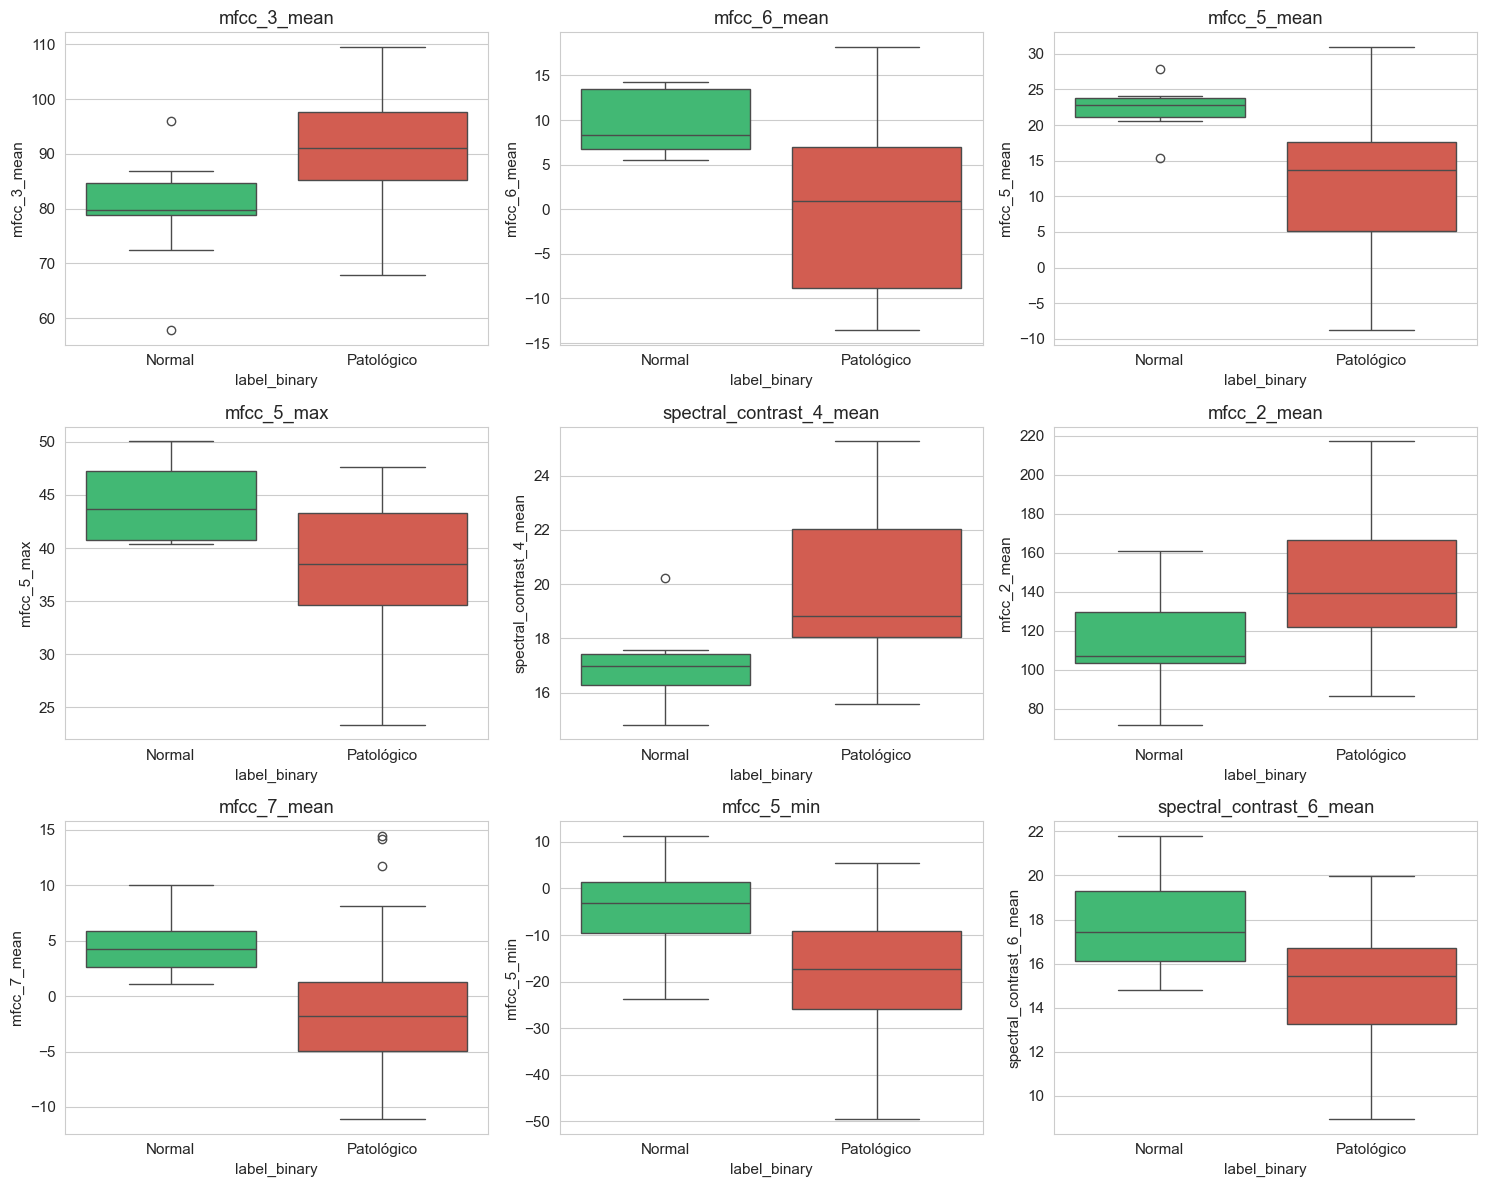

In [53]:
# Boxplots de top features por clase binaria
top_features = correlations_sorted.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feature in zip(axes.flat, top_features):
    sns.boxplot(data=hs_features, x='label_binary', y=feature, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Normal', 'Patológico'])
    ax.set_title(feature)

plt.tight_layout()
plt.savefig('../outputs/14_boxplots_top_features.png', dpi=150, bbox_inches='tight')

---
## 9. Conclusiones y decisiones para modelado

In [54]:
conclusions = {
    'Dataset': {
        'Heart Sounds': f'{len(hs)} muestras, {hs["Heart Sound Type"].nunique()} clases',
        'Lung Sounds': f'{len(ls)} muestras, {ls["Lung Sound Type"].nunique()} clases',
        'Mixed': f'{len(mix)} muestras (combinaciones)'
    },
    'Desbalance': {
        'HS Multiclase': 'Ratio 4.5:1 - Requiere balanceo',
        'LS Multiclase': 'Ratio 2.4:1 - Manejable',
        'HS Binario': 'Normal:9 vs Patológico:41',
        'LS Binario': 'Normal:12 vs Patológico:38'
    },
    'Features': {
        'Total extraídas': len(feature_cols),
        'Más discriminativas': correlations_sorted.head(5).index.tolist()
    },
    'Recomendaciones': [
        '1. Comenzar con clasificación binaria (Normal vs Patológico)',
        '2. Usar validación cruzada estratificada (k=5)',
        '3. Aplicar SMOTE o class_weight para desbalance',
        '4. Probar selección de features con importancia RF',
        '5. Normalizar features antes de SVM y LogReg'
    ]
}

In [55]:
# Mostrar conclusiones
for section, content in conclusions.items():
    print(f"\n{'='*50}")
    print(f" {section}")
    print('='*50)
    if isinstance(content, dict):
        for k, v in content.items():
            print(f"  {k}: {v}")
    elif isinstance(content, list):
        for item in content:
            print(f"  {item}")


 Dataset
  Heart Sounds: 50 muestras, 10 clases
  Lung Sounds: 50 muestras, 6 clases
  Mixed: 145 muestras (combinaciones)

 Desbalance
  HS Multiclase: Ratio 4.5:1 - Requiere balanceo
  LS Multiclase: Ratio 2.4:1 - Manejable
  HS Binario: Normal:9 vs Patológico:41
  LS Binario: Normal:12 vs Patológico:38

 Features
  Total extraídas: 106
  Más discriminativas: ['mfcc_3_mean', 'mfcc_6_mean', 'mfcc_5_mean', 'mfcc_5_max', 'spectral_contrast_4_mean']

 Recomendaciones
  1. Comenzar con clasificación binaria (Normal vs Patológico)
  2. Usar validación cruzada estratificada (k=5)
  3. Aplicar SMOTE o class_weight para desbalance
  4. Probar selección de features con importancia RF
  5. Normalizar features antes de SVM y LogReg


---
## Guardar datasets procesados para modelado

In [56]:
# Guardar con etiquetas
hs.to_csv('../outputs/hs_metadata_processed.csv', index=False)
ls.to_csv('../outputs/ls_metadata_processed.csv', index=False)
mix.to_csv('../outputs/mix_metadata_processed.csv', index=False)

In [57]:
# Resumen final
summary = pd.DataFrame({
    'Archivo': ['hs_features.csv', 'ls_features.csv', 'hs_metadata_processed.csv'],
    'Descripción': ['Features extraídas HS', 'Features extraídas LS', 'Metadata con etiquetas binarias'],
    'Filas': [len(hs_features), len(ls_features), len(hs)],
    'Uso': ['Input para modelos ML', 'Input para modelos ML', 'Referencia de etiquetas']
})
summary

,Archivo,Descripción,Filas,Uso
0,hs_features.csv,Features extraídas HS,50,Input para modelos ML
1,ls_features.csv,Features extraídas LS,35,Input para modelos ML
2,hs_metadata_processed.csv,Metadata con etiquetas binarias,50,Referencia de etiquetas
